In [53]:
import pandas as pd
import psycopg2
import networkx as nx
import matplotlib.pyplot as plt
from itertools import chain
from tqdm import tqdm
from sqlalchemy import create_engine

class GraphD:
    def __init__(self, db_params):
        """Initialize the recommender system with database connection parameters"""
        self.db_params = db_params
        self.conn = self._connect_db()
        self.df = self._load_recommendation_data()
        self.recipe_sim = self._load_recipe_weight()
        self.G = self.create_Graph_data()
        # self.subG = None

    def _connect_db(self):
        """Connect to PostgreSQL database using SQLAlchemy"""
        db_url = f"postgresql+psycopg2://{self.db_params['user']}:{self.db_params['password']}@{self.db_params['host']}:{self.db_params['port']}/{self.db_params['dbname']}"
        return create_engine(db_url)

    def _load_recommendation_data(self):
        """Load data using SQLAlchemy"""
        query = "SELECT * FROM recommendations"
        print('start to load recommendation data')
        return pd.read_sql(query, self.conn)
    
    def _load_recipe_weight(self):
        """Load data using SQLAlchemy"""
        query = "SELECT * FROM recipe_similarity_matrix"
        print('start to load recipe weight')
        return pd.read_sql(query, self.conn)
    
    def create_Graph_data(self):
        # initiate Graph
        self.G = nx.Graph()
        # node list
        users = list(self.df.user_name.unique())
        recipes = list(self.df.recipe_name.unique())
        keywords = list(self.df.keyword_collection)
        keywords = set(list(chain(*keywords)))
        cate = list(self.df.food_category.unique())

        # Add each nodes
        self.G.add_nodes_from(users, type='user_name')
        self.G.add_nodes_from(recipes, type='recipe_name')
        self.G.add_nodes_from(keywords, type='keyword')
        self.G.add_nodes_from(cate, type='category')

        for i in tqdm(range(len(self.df))):
            self.G.add_edge(self.df['user_name'][i], self.df['recipe_name'][i], stars=int(self.df['stars'][i]))
            self.G.add_edges_from([(self.df['recipe_name'][i], node, {"relation": 'keyword'}) for node in self.df['keyword_collection'][i]])
            self.G.add_edge(self.df['food_category'][i],self.df['recipe_name'][i], category="category")

        edges = [
            (row.user_name, key, {"relation": k1, "weight": float(item)})
            for row in self.df.itertuples()
            for k1 in row.recommend_result.keys()
            for key, item in row.recommend_result[k1].items()
        ]
        self.G.add_edges_from(edges)

        for idx, row in self.recipe_sim.iterrows():
            if row['similarity_score'] > 0.9:
                self.G.add_edge(row['recipe_1'], row['recipe_2'], weight=float(row['similarity_score']))
        return self.G

    def get_nodes_within_k_hops(self, start_node, k=1):
        # Find node in step 'k' by using BFS
        # self.create_Graph_data()
        nodes_within_k = set([start_node])
        for _ in range(k):
            new_nodes = set()
            for node in nodes_within_k:
                new_nodes.update(self.G.neighbors(node))
            nodes_within_k.update(new_nodes)
        self.G.subgraph(nodes_within_k)
        return self.G.subgraph(nodes_within_k)
    
    def filtering_edges(self, recipe_name, threshold_weight=0.97, threshold_stars=4.0, type='any'):
        """
        ✅ Among the nodes connected to a specific recipe node:
        •	Keep only those where weight ≥ threshold_weight OR stars ≥ threshold_stars.
        •	Include only the connected nodes where the type is in specific attribute.
        """
        if recipe_name not in self.G:
            print(f"❌ '{recipe_name}' There are not any node in graph.")
            return None

        filtered_edges = []

        # ✅ Check every edges that are connected to specific recipe node
        for neighbor in self.G.neighbors(recipe_name):
            edge_data = self.G.get_edge_data(recipe_name, neighbor)

            # ✅ Filtering condition #1: weight ≥ 0.97 OR stars ≥ 4
            weight_condition = edge_data.get("weight", 0) >= threshold_weight
            stars_condition = edge_data.get("stars", 0) >= threshold_stars

            # ✅ Filtering condition #w : type
            if type == 'any':
                if (weight_condition or stars_condition):
                    filtered_edges.append((recipe_name, neighbor))
            else:
                if (weight_condition or stars_condition) and self.G.nodes[neighbor].get("type") == type:
                    filtered_edges.append((recipe_name, neighbor))

        if not filtered_edges:
            print(f"❌ 'There are not any nodes in conditions that are connected to {recipe_name}.'")
            return None

        # ✅ Generate subgraph
        subG = self.G.edge_subgraph(filtered_edges)
        return subG

    def filter_edges_by_keyword(self, search_keyword, relation="keyword", type='recipe_name'):
        """       
        Among the edges connected to a node with a specific keyword:
	    •	Keep only the edges where the relation attribute is keyword.
	    •	Include only the connected nodes where the type is recipe_name.
        """
        if search_keyword not in self.G:
            print(f"❌ '{search_keyword}' There isn't any node.")
            return None

        filtered_edges = []

        # ✅ extract every edges that is connected to specific node
        for neighbor in self.G.neighbors(search_keyword):
            edge_data = self.G.get_edge_data(search_keyword, neighbor)

            # ✅ filtering condition : check if relation = 'keyword' and node's type = 'recipe_name'
            if relation != '':
                if edge_data.get("relation") == relation and self.G.nodes[neighbor].get("type") == type:
                    filtered_edges.append((search_keyword, neighbor))
            else:
                if self.G.nodes[neighbor].get("type") == type:
                    filtered_edges.append((search_keyword, neighbor))
        return self.G.edge_subgraph(filtered_edges)

    def graph_visualization(self, search_target, visual_type='K-Neighbor', k=1, threshold_weight=0.98, threshold_stars=4.0, relation="keyword", type='recipe_name'):
        if visual_type == 'K-Neighbor':
            subG = self.get_nodes_within_k_hops(search_target, k)
        elif visual_type == 'Control_weight':
            subG = self.filtering_edges(search_target, threshold_weight, threshold_stars, type)
        elif visual_type == 'Keyword':
            subG = self.filter_edges_by_keyword(search_target, relation, type)
            
        plt.figure(figsize=(10, 10))
        pos = nx.spring_layout(subG, seed=42)
        node_labels = {node: f"{node}\n({self.G.nodes[node]['type']})" for node in subG.nodes()}
        nx.draw(subG, with_labels=True, node_color="lightblue", labels=node_labels, 
                edge_color="gray", node_size=3500, font_size=10)
        edge_labels = {}
        for u, v, d in subG.edges(data=True):
            if "weight" in d:
                edge_labels[(u, v)] = f'W: {d["weight"]:.2f}'  # represent Weight value
            elif "relation" in d:   # represent Weight value
                edge_labels[(u, v)] = f'R: {d["relation"]}'
            elif "stars" in d:   # represent Weight value
                edge_labels[(u, v)] = f'Stars: {d["stars"]}'

        nx.draw_networkx_edge_labels(subG, pos, edge_labels=edge_labels, font_size=8, font_color="red")
        
        if visual_type == 'K-Neighbor':
            plt.title(f"Subgraph for Node {search_target} within {k} hops")
        elif visual_type == 'Control_weight':
            plt.title(f"Subgraph for Node {search_target} of which keywords are over {threshold_weight} in related score and {threshold_stars} in star score")
        elif visual_type == 'Keyword':
            plt.title(f"Subgraph for Node {search_target} of which keywords are type:{type} and relation:{relation}")
        plt.show()


In [2]:
from Graph_structure import GraphD

In [3]:
db_params = {
    "dbname": "mydb",
    "user": "user",
    "password": "pass",
    "host": "my_postgres",
    "port": "5432"
}

GB = GraphD(db_params)


start to load recommendation data
start to load recipe weight


100%|██████████| 17352/17352 [00:01<00:00, 9001.52it/s]


In [6]:
GB.G.nodes

NodeView(('Jeri326', 'Mark467', 'Barbara566', 'jeansch123', 'camper77', 'nikhita', 'Sandy1256', 'Towanka', 'Quest', 'Susannah953', 'jillanglemyer810', 'Leslie126', 'Cindy4876', 'Xzercie', 'KimberleeGerarden', 'TERESA062', 'Mary-Lynne', 'Petri', 'Marilyn034', 'Jeannette653', 'Scott967', 'Jane601', 'Brenda349', 'KY_Cook', 'smoonchie', 'Sandy326', 'Carole368', 'Kimosaabe', 'OliveCorn', 'LindaHernandez', 'ahmom', 'BlueBattery', 'ladykjt', 'Sue', 'Debi', 'gooch621', 'Patricia', 'Jose', 'Sheryl', 'annamossburg', 'CleoHill', 'Nca', 'katlynn', 'AshleyMcCauley', 'Roy', 'HenriettaBurdsall', 'Linda', 'Darlene Olson', 'nanatlh', 'Kyleigh', 'Bea', 'snker0521', 'PatriciaJones', 'YvonneHam', 'eileenmarston', 'BCBabies', "dylan's mama", 'Bonnie', 'MaryMc', 'TeQuilaClaybrooks', 'LisaValle', 'IanRobertson', 'joycerm53', 'Guest4548', 'mrscessna', 'ToniChurch', 'LauraYvonne', 'Deederboz', 'm.whitworth', 'klabelle9', 'qwm', 'JillShields', 'kvelthaus', '2124arizona', 'DanaFields', 'KarieCarter', 'BrandonSow

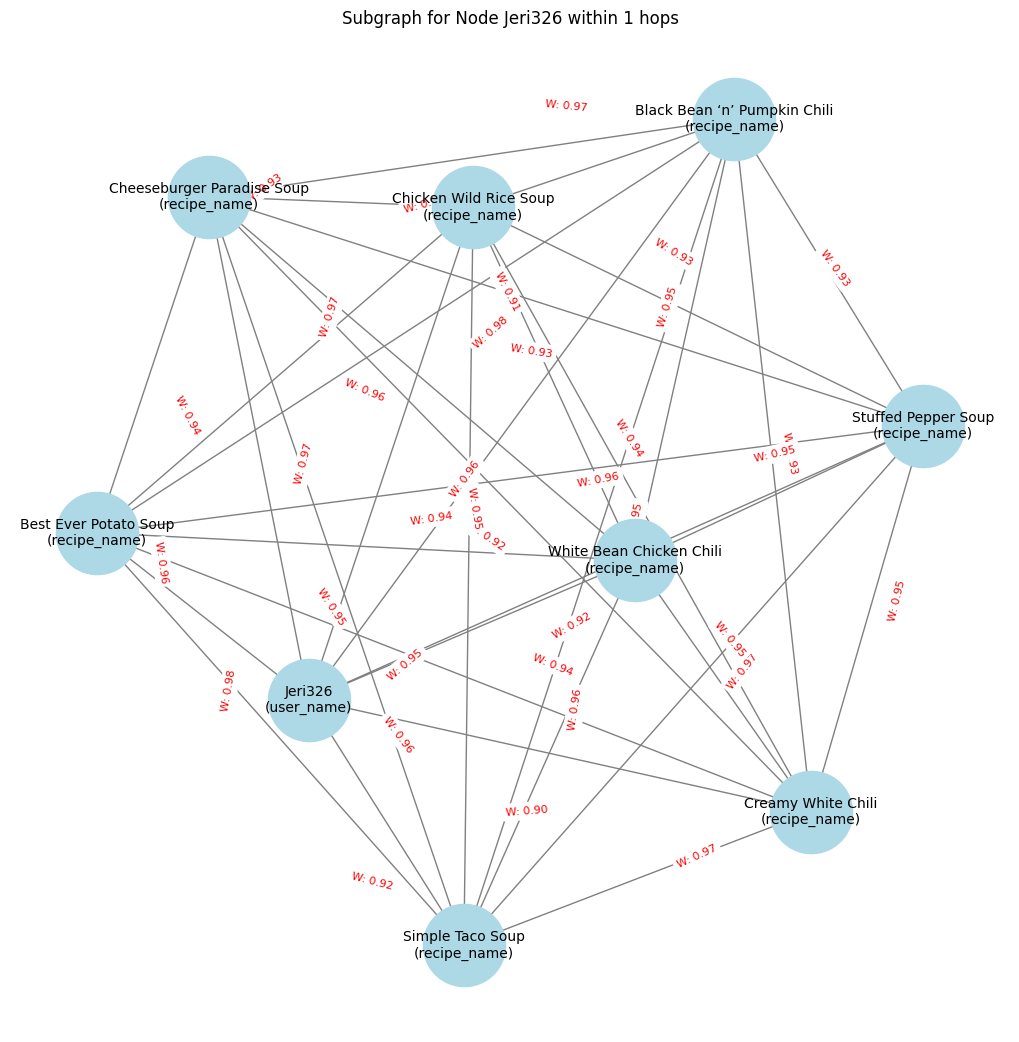

In [7]:
GB.graph_visualization('Jeri326', visual_type='K-Neighbor')
